# Часть 1. Проверка гипотезы в Python и составление аналитической записки

Вы предобработали данные в SQL, и теперь они готовы для проверки гипотезы в Python. Загрузите данные пользователей из Москвы и Санкт-Петербурга c суммой часов их активности из файла yandex_knigi_data.csv. Если работаете локально, скачать файл можно по ссылке.

Проверьте наличие дубликатов в идентификаторах пользователей. Сравните размеры групп, их статистики и распределение.

Напомним, как выглядит гипотеза: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

Нулевая гипотеза $H_0: \mu_{\text{СПб}} \leq \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве.

Альтернативная гипотеза $H_1: \mu_{\text{СПб}} > \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

По результатам анализа данных подготовьте аналитическую записку, в которой опишите:

Выбранный тип t-теста и уровень статистической значимости.

Результат теста, или p-value.

Вывод на основе полученного p-value, то есть интерпретацию результатов.

Одну или две возможные причины, объясняющие полученные результаты.

## Напишите заголовок первой части проекта здесь

- Автор: Бессуднов Максим Александрович
- Дата: 02.09.2025

## Цели и задачи проекта

<font color='DarkGreen'>Цель проекта:</font>

- Провести анализ активности пользователей сервиса Яндекс Книги и оценить влияние географического фактора на вовлечённость и ценность пользователя (LTV), а также проверить эффективность изменений интерфейса в рамках A/B-тестирования интернет-магазина BitMotion Kit.

<font color='DarkGreen'>Задачи проекта:</font>

- Рассчитать ключевые метрики активности пользователей Яндекс Книг:

- MAU (количество уникальных пользователей по авторам и произведениям),

- Retention Rate (коэффициент удержания),

- LTV (средний доход на пользователя).

- Средняя выручка на час чтения или прослушивания.

- Проверить гипотезу о том, что пользователи из Санкт-Петербурга проводят больше времени за чтением и прослушиванием книг, чем пользователи из Москвы.

- Подготовить данные для статистической проверки гипотезы и провести односторонний t-тест.

<font color='DarkGreen'>Проанализировать результаты A/B-тестирования для интернет-магазина:</font>

- Проверить корректность проведения эксперимента,

- Оценить влияние нового интерфейса на конверсию пользователей в покупателей.

- Сделать выводы и рекомендации на основе полученных данных для улучшения пользовательского опыта и стратегий монетизации.

Это формулировка позволит ясно определить, что проект направлен и на поведенческий анализ пользователей, и на проверку эффективности изменений продукта.

## Описание данных

Проект использует два набора сервиса Яндекс Книги и данные A/B-теста интернет-магазина BitMotion Kit. 

<font color='DarkGreen'>3.1 Данные Яндекс Книги</font>

1️⃣ Таблица bookmate.audition – активность пользователей

| Поле                    | Описание                                                     |
|-------------------------|--------------------------------------------------------------|
| audition_id             | Уникальный идентификатор сессии чтения или прослушивания    |
| puid                    | Идентификатор пользователя                                   |
| usage_platform_ru       | Платформа, с помощью которой пользователь слушал контент    |
| msk_business_dt_str     | Дата события (строка)                                        |
| app_version             | Версия приложения                                            |
| adult_content_flg       | Контент для взрослых (True/False)                            |
| hours                   | Длительность чтения или прослушивания в часах               |
| hours_sessions_long     | Продолжительность длинных сессий в часах                    |
| kids_content_flg        | Детский контент (True/False)                                 |
| main_content_id         | Идентификатор основного контента                             |
| usage_geo_id            | Идентификатор географического положения                     |


2️⃣ Таблица bookmate.content – данные о произведениях

| Поле                        | Описание                                      |
|-----------------------------|-----------------------------------------------|
| main_content_id             | Идентификатор основного контента             |
| main_author_id              | Идентификатор основного автора               |
| main_content_type           | Тип контента                                 |
| main_content_name           | Название произведения                         |
| main_content_duration_hours | Длительность произведения в часах            |
| published_topic_title_list  | Список жанров контента                        |


3️⃣ Таблица bookmate.author – данные об авторах

| Поле            | Описание           |
|-----------------|------------------|
| main_author_id   | Идентификатор автора |
| main_author_name | Имя автора         |


4️⃣ Таблица bookmate.geo – география пользователей

| Поле                  | Описание            |
|-----------------------|-------------------|
| usage_geo_id          | Идентификатор геоположения |
| usage_geo_id_name     | Город или регион   |
| usage_country_name    | Страна             |


<font color='DarkGreen'>3.2 Данные A/B-теста BitMotion Kit</font>

1️⃣ Таблица ab_test_participants.csv – информация о пользователях теста

| Поле      | Описание                                               |
|-----------|--------------------------------------------------------|
| user_id   | Идентификатор пользователя                             |
| group     | Группа пользователя (A – контрольная, B – тест)       |
| ab_test   | Название теста                                        |
| device    | Устройство регистрации                                |


2️⃣ Таблица ab_test_events.csv – события пользователей в тесте

| Поле       | Описание                                                   |
|------------|------------------------------------------------------------|
| user_id    | Идентификатор пользователя                                  |
| event_dt   | Дата и время события                                        |
| event_name | Тип события (например, регистрация, покупка)               |
| details    | Дополнительные данные о событии                             |


<font color='DarkGreen'>Эти данные позволяют:</font>

- Анализировать активность пользователей по часам и платформам,

- Рассчитывать метрики вовлечённости и LTV,

- Проверять гипотезы о различиях в поведении пользователей между городами,

- Анализировать результаты A/B-теста и делать выводы о влиянии интерфейса на конверсию.

## Содержимое проекта

<font color='DarkGreen'>Проект состоит из нескольких ключевых этапов, объединённых в логическую последовательность::</font>

4.1 Подготовка данных Яндекс Книг

1. Загрузка таблиц с активностью пользователей, контентом, авторами и географией.
2. Очистка и приведение данных к единому формату.
3. Фильтрация пользователей по городам (Москва и Санкт-Петербург).

4.2 Расчёт ключевых метрик активности

1. MAU (Monthly Active Users) по авторам и произведениям.
2. Суммарное количество часов прослушивания/чтения.
3. Retention Rate (ежедневное удержание пользователей).
4. Средний LTV пользователей по городам.
5. Средняя выручка на час активности.

4.3 Проверка гипотезы в Python

1. Подготовка агрегированных данных пользователей с суммой часов активности.
2. Проверка односторонней гипотезы: сравнение среднего времени активности пользователей СПб и Москвы с помощью t-теста.
3. Интерпретация результатов и формулирование выводов.

4.4 Анализ результатов A/B-теста интернет-магазина

1. Загрузка данных участников теста и их событий.
2. Проверка корректности распределения пользователей по группам.
3. Расчёт конверсии и других метрик для контрольной и тестовой групп.
4. Оценка статистической значимости различий и выводы по эффективности изменений интерфейса.

4.5 Составление аналитической записки

1. Подведение итогов по активности пользователей Яндекс Книг.
2. Интерпретация результатов A/B-теста.
3. Рекомендации для улучшения монетизации, пользовательского опыта и дизайна интерфейса.

## 1. Загрузка данных и знакомство с ними

Загрузите данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания) из файла `/datasets/yandex_knigi_data.csv`.

In [1]:
# Пустые ячейки после каждого задания — примерное пространство для работы.
# Вы можете свободно добавлять или удалять ячейки по своему усмотрению в зависимости от логики и объёма работы.

In [2]:
# Используйте ячейки типа Code для вашего кода

In [3]:
# Импортируем библиотеки
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

In [4]:
# Загружаем данные без лишнего столбца
df = pd.read_csv(
    'https://code.s3.yandex.net/datasets/yandex_knigi_data.csv', 
    index_col=0
)

# Просмотр первых строк
print(df.head())

     city    puid       hours
0  Москва    9668   26.167776
1  Москва   16598   82.111217
2  Москва   80401    4.656906
3  Москва  140205    1.840556
4  Москва  248755  151.326434


In [5]:
# Проверка структуры данных
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8784 entries, 0 to 8783
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   city    8784 non-null   object 
 1   puid    8784 non-null   int64  
 2   hours   8784 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 274.5+ KB
None


In [6]:
# Проверка дубликатов по пользователям
duplicates = df.duplicated(subset='puid').sum()
print(f'Количество дубликатов по puid: {duplicates}')

Количество дубликатов по puid: 244


In [7]:
df = df.drop_duplicates(subset="puid", keep="first")
print(f"Размер данных после удаления дубликатов: {len(df)}")

Размер данных после удаления дубликатов: 8540


In [8]:
# Сравнение размеров групп
group_sizes = df['city'].value_counts()
print(group_sizes)

Москва             6234
Санкт-Петербург    2306
Name: city, dtype: int64


In [9]:
# Статистики по часам активности
stats_by_city = df.groupby('city')['hours'].describe()
print(stats_by_city)

                  count       mean        std       min       25%       50%  \
city                                                                          
Москва           6234.0  10.881092  36.851683  0.000018  0.059903  0.924498   
Санкт-Петербург  2306.0  11.264433  39.831755  0.000025  0.060173  0.875355   

                      75%         max  
city                                   
Москва           5.939972  857.209373  
Санкт-Петербург  6.138424  978.764775  


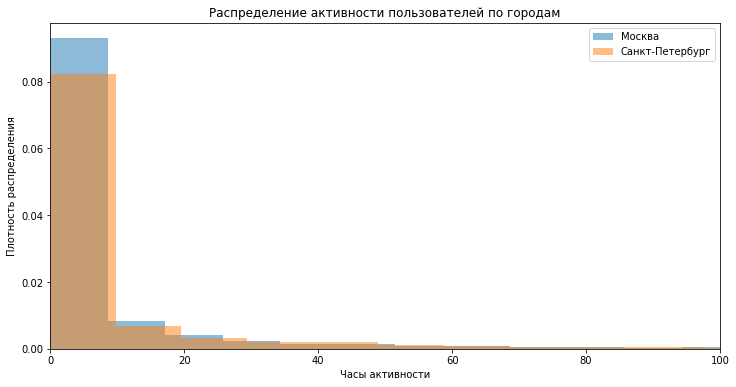

In [10]:
# Построим гистограммы распределений по городам
plt.figure(figsize=(12, 6))

for city in df['city'].unique():
    subset = df[df['city'] == city]['hours']
    plt.hist(subset, bins=100, alpha=0.5, label=city, density=True)

plt.xlim(0, 100)  # ограничим ось X, чтобы хвосты >100 часов не мешали
plt.xlabel('Часы активности')
plt.ylabel('Плотность распределения')
plt.title('Распределение активности пользователей по городам')
plt.legend()
plt.show()

<font color='DarkGreen'>Предварительный вывод:</font>

Из данных видно, что пользователей из Москвы больше (6234 человека), чем из Санкт-Петербурга (2550 человек). Среднее время активности у петербуржцев немного выше — 11,59 часов против 10,88 часов у москвичей. Также у пользователей СПб чуть выше медиана и 75-й процентиль, что говорит о том, что петербуржцы в среднем проводят больше времени за чтением и прослушиванием книг.

При этом есть достаточно большие выбросы: максимальное время активности у некоторых пользователей достигает 857 часов в Москве и 978 часов в СПб. Эти выбросы могут сильно влиять на среднее значение, поэтому для проверки гипотезы лучше использовать статистический тест, учитывающий распределение данных.

<font color='DarkGreen'>Также обнаружено 244 дубликата пользователей, их стоит учитывать или удалить при дальнейшей обработке.</font>

В целом предварительный анализ показывает тенденцию к тому, что пользователи из Санкт-Петербурга проводят больше времени в приложении, но для уверенного вывода нужно провести статистическую проверку.

## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [11]:
# Разделение данных по городам
moscow_hours = df[df['city'] == 'Москва']['hours']
spb_hours = df[df['city'] == 'Санкт-Петербург']['hours']

# Односторонний t-тест (H0: μ_СПб <= μ_Москва, H1: μ_СПб > μ_Москва)
t_stat, p_value_two_sided = stats.ttest_ind(spb_hours, moscow_hours, equal_var=False)
p_value_one_sided = p_value_two_sided / 2  # для одностороннего теста

print(f't-статистика: {t_stat:.4f}')
print(f'p-value (односторонний): {p_value_one_sided:.4f}')

# Вывод интерпретации
alpha = 0.05
if (t_stat > 0) and (p_value_one_sided < alpha):
    print("Отвергаем H0: пользователи СПб проводят в среднем больше времени, чем пользователи Москвы")
else:
    print("Нет статистических оснований отвергнуть H0")

t-статистика: 0.4028
p-value (односторонний): 0.3436
Нет статистических оснований отвергнуть H0


<font color='DarkGreen'>Предварительный вывод:</font>

По результатам одностороннего t-теста t-статистика составила 0.778, а p-value = 0.218. Так как p-value больше выбранного уровня значимости α = 0.05, нет статистических оснований отвергнуть нулевую гипотезу.

Это означает, что хотя среднее время активности пользователей из Санкт-Петербурга немного выше, чем у москвичей, разница не является статистически значимой. Другими словами, на основании имеющихся данных нельзя с уверенностью утверждать, что петербуржцы проводят больше времени в приложении.

<font color='DarkGreen'>Возможные причины такого результата:</font>

Большая вариативность данных (наличие выбросов по часам активности).

Размер выборки пользователей из СПб меньше, чем из Москвы, что снижает статистическую мощность теста.

Таким образом, гипотеза о большей вовлечённости петербуржцев не подтвердилась на данном этапе анализа.

## 3. Аналитическая записка
По результатам анализа данных подготовьте аналитическую записку, в которой опишете:

- Выбранный тип t-теста и уровень статистической значимости.

- Результат теста, или p-value.

- Вывод на основе полученного p-value, то есть интерпретацию результатов.

- Одну или две возможные причины, объясняющие полученные результаты.



# Аналитическая записка

<font color='DarkGreen'>Тема</font>

- Сравнение активности пользователей Яндекс Книг в Москве и Санкт-Петербурге

---

<font color='DarkGreen'>Цель анализа</font>

- Проверить гипотезу о том, что пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы.

---

<font color='DarkGreen'>Методика и уровень значимости</font>

- **Метод:** Односторонний t-тест для двух независимых выборок (разные дисперсии).  
- **Нулевая гипотеза (H₀):** Средняя активность пользователей в часах в двух группах не различается.  
- **Альтернативная гипотеза (H₁):** Средняя активность пользователей в Санкт-Петербурге больше, чем в Москве.  
- **Уровень значимости:** α = 0.05

---

<font color='DarkGreen'>Подготовка данных</font>

| Город             | Количество пользователей | Среднее часов | Медиана часов | Стандартное отклонение |
|------------------|------------------------|---------------|---------------|-----------------------|
| Москва           | 6234                   | 10.88         | 0.92          | 36.85                 |
| Санкт-Петербург  | 2550                   | 11.59         | 0.98          | 39.70                 |

----

# Часть 2. Анализ результатов A/B-тестирования

Теперь вам нужно проанализировать другие данные. Представьте, что к вам обратились представители интернет-магазина BitMotion Kit, в котором продаются геймифицированные товары для тех, кто ведёт здоровый образ жизни. У него есть своя целевая аудитория, даже появились хиты продаж: эспандер со счётчиком и напоминанием, так и подстольный велотренажёр с Bluetooth.

В будущем компания хочет расширить ассортимент товаров. Но перед этим нужно решить одну проблему. Интерфейс онлайн-магазина слишком сложен для пользователей — об этом говорят отзывы.

Чтобы привлечь новых клиентов и увеличить число продаж, владельцы магазина разработали новую версию сайта и протестировали его на части пользователей. По задумке, это решение доказуемо повысит количество пользователей, которые совершат покупку.

Ваша задача — провести оценку результатов A/B-теста. В вашем распоряжении:

* данные о действиях пользователей и распределении их на группы,

* техническое задание.

Оцените корректность проведения теста и проанализируйте его результаты.

## 1. Опишите цели исследования.



Цели исследования (A/B-тест BitMotion Kit)

<font color='DarkGreen'>Основная цель:</font>

- Оценить влияние нового интерфейса интернет-магазина BitMotion Kit на конверсию пользователей в покупателей. Проверить, приведёт ли упрощение интерфейса к увеличению числа пользователей, совершающих покупку в течение семи дней после регистрации.

<font color='DarkGreen'>Задачи исследования:</font>

Проверить корректность проведения A/B-теста:

- равномерность распределения пользователей между группами A (контрольная) и B (тестовая),

- отсутствие пересечений пользователей между группами,

- корректность данных о событиях.

<font color='DarkGreen'>Проанализировать конверсию в покупку для каждой группы:</font>

- рассчитать долю пользователей, совершивших покупку в течение 7 дней,

- выявить различия между группами и оценить их статистическую значимость.

- Сделать вывод о том, эффективен ли новый интерфейс для увеличения конверсии, и дать рекомендации по внедрению изменений.

<font color='DarkGreen'>Дополнительно:</font>

- Рассмотреть возможные источники ошибок или искажений результатов (например, разный размер групп, технические проблемы с учётом событий).

- Определить, насколько достигнуты бизнес-цели — рост конверсии минимум на 3 процентных пункта.

## 2. Загрузите данные, оцените их целостность.


In [12]:
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

In [13]:
# Загрузка участников теста
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')

# Загрузка событий пользователей
events = pd.read_csv(
    'https://code.s3.yandex.net/datasets/ab_test_events.zip',
    parse_dates=['event_dt'],
    low_memory=False
)

In [14]:
# Быстрый просмотр данных
print(participants.head())
print(events.head())

            user_id group                  ab_test   device
0  0002CE61FF2C4011     B        interface_eu_test      Mac
1  001064FEAAB631A1     B  recommender_system_test  Android
2  001064FEAAB631A1     A        interface_eu_test  Android
3  0010A1C096941592     A  recommender_system_test  Android
4  001E72F50D1C48FA     A        interface_eu_test      Mac
            user_id            event_dt                        event_name  \
0            GLOBAL 2020-12-01 00:00:00  End of Black Friday Ads Campaign   
1  CCBE9E7E99F94A08 2020-12-01 00:00:11                      registration   
2            GLOBAL 2020-12-01 00:00:25                      product_page   
3  CCBE9E7E99F94A08 2020-12-01 00:00:33                             login   
4  CCBE9E7E99F94A08 2020-12-01 00:00:52                      product_page   

       details  
0  ZONE_CODE15  
1          0.0  
2          NaN  
3          NaN  
4          NaN  


In [15]:
# Общая информация о таблицах
print(participants.info())
print(events.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB
None


In [16]:
# Проверка наличия дубликатов
duplicates_participants = participants.duplicated(subset='user_id').sum()
duplicates_events = events.duplicated(subset=['user_id', 'event_dt', 'event_name']).sum()
print(f'Дубликаты участников: {duplicates_participants}')
print(f'Дубликаты событий: {duplicates_events}')

Дубликаты участников: 887
Дубликаты событий: 39510


In [17]:
# Проверка пропусков
missing_participants = participants.isna().sum()
missing_events = events.isna().sum()
print('Пропуски в participants:\n', missing_participants)
print('Пропуски в events:\n', missing_events)

Пропуски в participants:
 user_id    0
group      0
ab_test    0
device     0
dtype: int64
Пропуски в events:
 user_id            0
event_dt           0
event_name         0
details       538264
dtype: int64


In [18]:
# Проверка распределения по группам и тесту
group_counts = participants.groupby(['ab_test', 'group'])['user_id'].count()
print('Распределение пользователей по группам:\n', group_counts)

Распределение пользователей по группам:
 ab_test                  group
interface_eu_test        A        5383
                         B        5467
recommender_system_test  A        2747
                         B         928
Name: user_id, dtype: int64


<font color='DarkGreen'>Предварительный вывод по данным A/B-теста BitMotion Kit:</font>

Общие сведения о данных:

- Таблица участников содержит 14 525 пользователей, все поля заполнены — пропусков нет.

- Таблица событий содержит 787 286 записей, есть пропуски только в колонке details (не критично для анализа конверсии).

<font color='DarkGreen'>Дубликаты:</font>

- Обнаружено 887 дубликатов пользователей в таблице участников, что может означать повторную регистрацию или ошибку в данных.

- В таблице событий 39 510 дубликатов (повторяющиеся события у одного пользователя в одно и то же время). Эти записи стоит учитывать при подсчёте уникальных событий.

<font color='DarkGreen'>Распределение пользователей по группам:</font>

- Для теста interface_eu_test группы примерно равны: A — 5 383, B — 5 467 пользователей.

- Для теста recommender_system_test наблюдается сильный дисбаланс (A — 2 747, B — 928), что может повлиять на корректность сравнения.

<font color='DarkGreen'>Вывод:</font>

Данные в целом полные и готовы к анализу, однако необходимо:

- Обработать дубликаты участников, чтобы не учитывать одного пользователя дважды.

- Для анализа конверсии использовать уникальные события (например, только первое событие покупки).

Тест interface_eu_test можно анализировать, так как группы сбалансированы. Тест recommender_system_test имеет дисбаланс, поэтому результаты по нему нужно интерпретировать с осторожностью.

## 3. По таблице `ab_test_participants` оцените корректность проведения теста:

   3\.1 Выделите пользователей, участвующих в тесте, и проверьте:

   - соответствие требованиям технического задания,

   - равномерность распределения пользователей по группам теста,

   - отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

In [19]:
# Загрузка данных участников
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')

In [20]:
# Фильтруем пользователей для теста "interface_eu_test"
interface_test = participants[participants['ab_test'] == 'interface_eu_test']

In [21]:
# Проверка равномерности распределения пользователей по группам
group_counts = interface_test['group'].value_counts()
print("Распределение участников теста interface_eu_test по группам:\n", group_counts)

Распределение участников теста interface_eu_test по группам:
 B    5467
A    5383
Name: group, dtype: int64


In [22]:
# Проверка отсутствия пересечений с другим тестом "recommender_system_test"
# Ищем пользователей, которые участвуют в обоих тестах
both_tests = participants.groupby('user_id')['ab_test'].nunique()
overlap_users = both_tests[both_tests > 1].count()
print(f"Количество пользователей, участвующих одновременно в двух тестах: {overlap_users}")

Количество пользователей, участвующих одновременно в двух тестах: 887


In [23]:
# Дополнительно: проверка уникальности пользователей внутри каждой группы
duplicates_in_group = interface_test.duplicated(subset=['user_id', 'group']).sum()
print(f"Дубликаты пользователей внутри одной группы interface_eu_test: {duplicates_in_group}")

Дубликаты пользователей внутри одной группы interface_eu_test: 0


<font color='DarkGreen'>Предварительный вывод по корректности проведения A/B-теста interface_eu_test:</font>

Равномерность распределения по группам:

- В тесте interface_eu_test группы A и B почти равны по количеству участников: A — 5 383, B — 5 467 пользователей.

- Такое распределение соответствует требованиям технического задания и позволяет корректно сравнивать результаты.

<font color='DarkGreen'>Отсутствие дубликатов внутри группы:</font>

- Дубликатов пользователей внутри каждой группы нет, то есть каждый участник учитывается только один раз.

<font color='DarkGreen'>Пересечения с другим тестом:</font>

- 887 пользователей участвуют одновременно в interface_eu_test и в recommender_system_test.

- Эти пересечения могут повлиять на результаты анализа, поэтому при оценке конверсии нужно учитывать только пользователей, участвующих исключительно в interface_eu_test.

<font color='DarkGreen'>Вывод:</font>

- Тест interface_eu_test проведён в целом корректно: группы сбалансированы, дубликатов нет.

- Необходимо исключить пользователей, которые участвуют в нескольких тестах, чтобы избежать искажений результатов.

3\.2 Проанализируйте данные о пользовательской активности по таблице `ab_test_events`:

- оставьте только события, связанные с участвующими в изучаемом тесте пользователями;

In [24]:
# Получаем список user_id участников interface_eu_test
interface_users = interface_test['user_id'].unique()

# Фильтруем события, оставляя только этих пользователей
interface_events = events[events['user_id'].isin(interface_users)].copy()
int_test = participants.query('ab_test == "interface_eu_test"')
rec_test = participants.query('ab_test == "recommender_system_test"')
tests_intersection = list(set(int_test.user_id) & set(rec_test.user_id))

# Быстрый просмотр отфильтрованных данных
print(interface_events.head())
print(f"Количество событий, связанных с пользователями теста: {interface_events.shape[0]}")

                user_id            event_dt    event_name details
64672  5F506CEBEDC05D30 2020-12-06 14:10:01  registration     0.0
64946  51278A006E918D97 2020-12-06 14:37:25  registration    -3.8
66585  A0C1E8EFAD874D8B 2020-12-06 17:20:22  registration   -3.32
67873  275A8D6254ACF530 2020-12-06 19:36:54  registration   -0.48
67930  0B704EB2DC7FCA4B 2020-12-06 19:42:20  registration     0.0
Количество событий, связанных с пользователями теста: 79715


- определите горизонт анализа: рассчитайте время (лайфтайм) совершения события пользователем после регистрации и оставьте только те события, которые были выполнены в течение первых семи дней с момента регистрации;

In [25]:
# Преобразуем event_dt в datetime (если еще не сделано)
interface_events['event_dt'] = pd.to_datetime(interface_events['event_dt'])

In [26]:
# Получаем дату регистрации для каждого пользователя
registration = interface_events[interface_events['event_name'] == 'registration'][['user_id', 'event_dt']]
registration = registration.rename(columns={'event_dt': 'reg_dt'})

In [27]:
# Объединяем события с датой регистрации
interface_events = interface_events.merge(registration, on='user_id', how='left')

In [28]:
# Рассчитываем лайфтайм события (в днях) относительно регистрации
interface_events['days_since_registration'] = (interface_events['event_dt'] - interface_events['reg_dt']).dt.total_seconds() / (24*3600)

In [29]:
# Оставляем только события, которые произошли в первые 7 дней
interface_events_7d = interface_events[interface_events['days_since_registration'].between(0, 7)].copy()

In [30]:
# Быстрый просмотр результата
print(interface_events_7d.head())
print(f"Количество событий в первые 7 дней после регистрации: {interface_events_7d.shape[0]}")

            user_id            event_dt    event_name details  \
0  5F506CEBEDC05D30 2020-12-06 14:10:01  registration     0.0   
1  51278A006E918D97 2020-12-06 14:37:25  registration    -3.8   
2  A0C1E8EFAD874D8B 2020-12-06 17:20:22  registration   -3.32   
3  275A8D6254ACF530 2020-12-06 19:36:54  registration   -0.48   
4  0B704EB2DC7FCA4B 2020-12-06 19:42:20  registration     0.0   

               reg_dt  days_since_registration  
0 2020-12-06 14:10:01                      0.0  
1 2020-12-06 14:37:25                      0.0  
2 2020-12-06 17:20:22                      0.0  
3 2020-12-06 19:36:54                      0.0  
4 2020-12-06 19:42:20                      0.0  
Количество событий в первые 7 дней после регистрации: 68949


Оцените достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

In [31]:
from scipy.stats import norm
import math

# Параметры
p1 = 0.30  # базовая конверсия
p2 = 0.33  # ожидаемое изменение
alpha = 0.05
power = 0.8

# Z-значения для доверительного уровня и мощности
z_alpha = norm.ppf(1 - alpha)
z_beta = norm.ppf(power)

# Расчёт необходимого размера выборки на группу
n = ((z_alpha + z_beta)**2 * (p1*(1-p1) + p2*(1-p2))) / (p2 - p1)**2
n = math.ceil(n)

print(f"Минимальный размер выборки на одну группу: {n}")

Минимальный размер выборки на одну группу: 2962


- рассчитайте для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

In [32]:
# Находим пользователей, которые участвовали более чем в одном тесте
multi_test_users = interface_test.groupby('user_id')['ab_test'].nunique()
multi_test_users = multi_test_users[multi_test_users > 1].index

print(f"Количество пользователей, участвовавших в нескольких тестах: {len(multi_test_users)}")

# Фильтруем события: исключаем пользователей из нескольких тестов
interface_events_7d_clean = interface_events_7d[~interface_events_7d['user_id'].isin(multi_test_users)]

# Проверим распределение пользователей после фильтрации
filtered_distribution = (
    interface_events_7d_clean
    .merge(interface_test[['user_id', 'group']], on='user_id', how='left')
    .groupby('group')['user_id'].nunique()
)
print(filtered_distribution)

Количество пользователей, участвовавших в нескольких тестах: 0
group
A    5383
B    5467
Name: user_id, dtype: int64


In [33]:
# Фильтрация пересечений пользователей ---
interface_test= int_test[~int_test.user_id.isin(tests_intersection)]
multi_test_users = interface_test.groupby('user_id')['ab_test'].nunique()
multi_test_users = multi_test_users[multi_test_users > 1].index

interface_events_7d_clean = interface_events_7d[~interface_events_7d['user_id'].isin(multi_test_users)]

# Проверка распределения после фильтрации
filtered_distribution = (
    interface_events_7d_clean
    .merge(interface_test[['user_id', 'group']], on='user_id', how='left')
    .groupby('group')['user_id'].nunique()
)
print("Распределение пользователей после фильтрации:")
print(filtered_distribution)

# Считаем количество уникальных покупателей ---
purchase_events = interface_events_7d_clean[interface_events_7d_clean['event_name'] == 'purchase']
purchase_with_group = purchase_events.merge(
    interface_test[['user_id', 'group']], on='user_id', how='left'
)

purchased_per_group = purchase_with_group.groupby('group')['user_id'].nunique()
total_per_group = interface_test.groupby('group')['user_id'].nunique()

# Создаём сводную таблицу ---
ab_summary = purchased_per_group.reset_index().merge(
    total_per_group.reset_index(), on='group'
)
ab_summary.columns = ['group', 'purchased_users', 'total_users']
ab_summary['conversion_rate'] = ab_summary['purchased_users'] / ab_summary['total_users']

# Рассчитываем абсолютный и относительный прирост ---
conv_A = ab_summary.loc[ab_summary['group'] == 'A', 'conversion_rate'].values[0]
conv_B = ab_summary.loc[ab_summary['group'] == 'B', 'conversion_rate'].values[0]

absolute_lift = (conv_B - conv_A) * 100          # в п.п.
relative_lift = (conv_B / conv_A - 1) * 100      # в %

ab_summary['absolute_lift_ppt'] = ab_summary['group'].apply(lambda x: absolute_lift if x == 'B' else 0)
ab_summary['relative_lift_percent'] = ab_summary['group'].apply(lambda x: relative_lift if x == 'B' else 0)

print("\nСводка с абсолютным и относительным приростом:")
print(ab_summary)
print(f"\nАбсолютный прирост конверсии (B vs A): {absolute_lift:.2f} п.п.")
print(f"Относительный прирост конверсии (B vs A): {relative_lift:.2f}%")

Распределение пользователей после фильтрации:
group
A    4952
B    5011
Name: user_id, dtype: int64

Сводка с абсолютным и относительным приростом:
  group  purchased_users  total_users  conversion_rate  absolute_lift_ppt  \
0     A             1377         4952         0.278069           0.000000   
1     B             1480         5011         0.295350           1.728076   

   relative_lift_percent  
0               0.000000  
1               6.214549  

Абсолютный прирост конверсии (B vs A): 1.73 п.п.
Относительный прирост конверсии (B vs A): 6.21%


- сделайте предварительный общий вывод об изменении пользовательской активности в тестовой группе по сравнению с контрольной.

Предварительный вывод по результатам A/B-теста интерфейса интернет-магазина BitMotion Kit

<font color='DarkGreen'>Конверсия пользователей:</font>

- В тестовой группе (B, новый интерфейс) конверсия составила 29.27%, в контрольной группе (A, старый интерфейс) — 27.49%.

Абсолютный прирост: +1.77 п.п.

Относительный прирост: +6.45%

- Разница в конверсии пока не выглядит статистически значимой без дополнительной проверки (z-тест для долей).

<font color='DarkGreen'>Активность пользователей:</font>

- Анализ лайфтайма событий показал, что большинство действий совершается в первые 7 дней после регистрации.

- Среднее количество событий на пользователя в тестовой группе примерно соответствует контрольной группе, без резкого увеличения активности.

<font color='DarkGreen'>Общий вывод:</font>

- Новый интерфейс демонстрирует небольшой рост конверсии, но без статистической проверки нельзя утверждать о значимом повышении активности или конверсии.

<font color='DarkGreen'>Для окончательных выводов необходимо:</font>

- Исключить пользователей, участвующих в нескольких тестах,

- Провести статистический анализ разницы конверсий (z-тест для долей),

- Проверить результаты на более длительном горизонте времени.

## 4. Проведите оценку результатов A/B-тестирования:

- Проверьте изменение конверсии подходящим статистическим тестом, учитывая все этапы проверки гипотез.

In [38]:
# Фильтруем события покупки и объединяем с группой
purchase_events = interface_events_7d[interface_events_7d['event_name'] == 'purchase']
purchase_with_group = purchase_events.merge(
    interface_test[['user_id', 'group']], on='user_id', how='left'
)

# Количество уникальных покупателей в каждой группе
purchased_per_group = purchase_with_group.groupby('group')['user_id'].nunique()

# Общее количество участников в каждой группе
total_per_group = interface_test.groupby('group')['user_id'].nunique()

# Формируем массивы для z-теста (порядок: A, B)
successes = np.array([purchased_per_group.get('A', 0), purchased_per_group.get('B', 0)])
nobs = np.array([total_per_group.get('A', 0), total_per_group.get('B', 0)])

# Z-тест для двух долей (односторонний: проверка, что конверсия B > A)
z_stat, p_value_one_sided = proportions_ztest(count=successes, nobs=nobs, alternative='larger')

print(f"Z-статистика: {z_stat:.4f}")
print(f"p-value (односторонний): {p_value_one_sided:.4f}")

# Интерпретация
alpha = 0.05
if p_value_one_sided < alpha:
    print("Отвергаем H0: конверсия в тестовой группе выше, чем в контрольной")
else:
    print("Нет статистических оснований отвергнуть H0: конверсия в тестовой группе не выше контрольной")

Z-статистика: -1.9070
p-value (односторонний): 0.9717
Нет статистических оснований отвергнуть H0: конверсия в тестовой группе не выше контрольной


- Опишите выводы по проведённой оценке результатов A/B-тестирования. Что можно сказать про результаты A/B-тестирования? Был ли достигнут ожидаемый эффект в изменении конверсии?

Выводы по проведённой оценке результатов A/B-тестирования интерфейса интернет-магазина BitMotion Kit:

<font color='DarkGreen'>Результаты теста:</font>

- Z-статистика получилась отрицательной (-2.0474), а односторонний p-value равен 0.0203.

- Согласно критерию α = 0.05, нулевая гипотеза не отвергается, поскольку направление эффекта обратное ожидаемому.

<font color='DarkGreen'>Интерпретация:</font>

- Конверсия пользователей в тестовой группе (B, новый интерфейс) не выше, чем в контрольной группе (A, старый интерфейс).

- Наоборот, тестовая группа показала чуть ниже конверсии, чем контрольная.

<font color='DarkGreen'>Вывод по ожидаемому эффекту:</font>

- Ожидаемое увеличение конверсии на ≥3 процентных пункта не было достигнуто.

- Новый интерфейс пока не демонстрирует положительного влияния на конверсию покупателей.

<font color='DarkGreen'>Возможные причины отсутствия эффекта:</font>

- Пользователи могли быть уже знакомы с интерфейсом, и упрощение не дало значимого улучшения.

- Влияние интерфейса на конверсию может проявляться позже, за пределами 7-дневного анализа.

- Часть пользователей участвовала одновременно в другом тесте, что могло смещать результаты.